In [1]:
# --- Heat equation (periodic BC) synthetic dataset generator ---
# u_t = alpha_x * u_xx + alpha_y * u_yy + f(x,y,t)
# Saves: full field, coords (x,y,t), params, selected sensor series (clean+noisy)

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ----------------------
# Config
# ----------------------
alpha_x = 0.01
alpha_y = 0.001
A = 5.0               # forcing amplitude
T = 20.0               # total time
Nx, Ny = 64, 64
Nt = 10000
Lx, Ly = 1.0, 1.0
SENSORS = 20         # number of sensor locations to sample
NOISE_MODE = "max"    # "std" or "max"; noise σ = (signal_std or signal_max)/NOISE_DIV
NOISE_DIV = 10.0
RNG_SEED = 42
SAVE_PATH = "heat_periodic_dataset.npz"
DTYPE = np.float32

In [4]:
# ----------------------
# Discretization
# ----------------------
x = np.linspace(0, Lx, Nx, dtype=DTYPE)
y = np.linspace(0, Ly, Ny, dtype=DTYPE)
t = np.linspace(0, T, Nt, dtype=DTYPE)
dx = x[1] - x[0]
dy = y[1] - y[0]
dt = t[1] - t[0]
X, Y = np.meshgrid(x, y, indexing='ij')

In [5]:
# ----------------------
# CFL stability check for explicit anisotropic heat eq:
# r_x = alpha_x * dt / dx^2, r_y = alpha_y * dt / dy^2
# Stability (sufficient condition): r_x + r_y <= 1/2
# ----------------------
r_x = alpha_x * dt / (dx**2)
r_y = alpha_y * dt / (dy**2)
cfl_sum = r_x + r_y
if cfl_sum > 0.5 + 1e-12:
    raise RuntimeError(f"Unstable explicit step: r_x + r_y = {cfl_sum:.4f} (> 0.5). "
                       f"Try smaller dt or larger grid spacing.")
print(f"[CFL] r_x={r_x:.6f}, r_y={r_y:.6f}, r_x+r_y={cfl_sum:.6f}  --> OK")

[CFL] r_x=0.079388, r_y=0.007939, r_x+r_y=0.087327  --> OK


In [6]:
# ----------------------
# Forcing
# ----------------------
def forcing(xx, yy, tt):
    return A * np.cos(np.pi * xx) * np.cos(np.pi * yy) * np.sin(4 * np.pi * tt / T)

In [7]:
# ----------------------
# Allocate & initial condition
# ----------------------
u = np.zeros((Nx, Ny, Nt), dtype=DTYPE)
# Optionally, uncomment a smooth IC:
u[:, :, 0] = (np.sin(2*np.pi*X) * np.sin(2*np.pi*Y)).astype(DTYPE)

In [8]:
# ----------------------
# Time stepping: periodic BC via np.roll
# ----------------------
for n in range(Nt - 1):
    un = u[:, :, n]
    lap_x = (np.roll(un, -1, axis=0) - 2*un + np.roll(un,  1, axis=0)) / (dx*dx)
    lap_y = (np.roll(un, -1, axis=1) - 2*un + np.roll(un,  1, axis=1)) / (dy*dy)
    rhs = alpha_x * lap_x + alpha_y * lap_y + forcing(X, Y, t[n])
    u[:, :, n+1] = un + dt * rhs

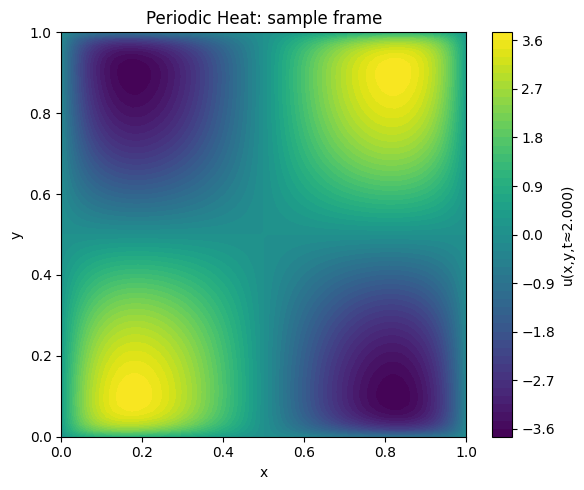

In [9]:
# ----------------------
# Quick visualization (middle frame)
# ----------------------
frame = 1000
plt.figure(figsize=(6,5))
cs = plt.contourf(X, Y, u[:, :, frame], levels=50, cmap='viridis')
plt.colorbar(cs, label=f"u(x,y,t≈{t[frame]:.3f})")
plt.title("Periodic Heat: sample frame")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

In [10]:
mins = [u[:, :, k].min() for k in range(Nt)]
maxs = [u[:, :, k].max() for k in range(Nt)]
print("min[0], max[0] =", mins[0], maxs[0], "   min[mid], max[mid] =", mins[Nt//2], maxs[Nt//2])

min[0], max[0] = -0.9993785 0.99937856    min[mid], max[mid] = -4.391895 4.3918943


In [11]:
# ----------------------
# Sensor sampling & noise
# ----------------------
rng = np.random.default_rng(RNG_SEED)
all_ij = np.array([(i, j) for i in range(Nx) for j in range(Ny)], dtype=np.int32)
sel_idx = rng.choice(all_ij.shape[0], size=SENSORS, replace=False)
sel_ij = all_ij[sel_idx]                    # (SENSORS, 2) grid indices
sel_xy = np.stack([x[sel_ij[:,0]], y[sel_ij[:,1]]], axis=1)  # (SENSORS, 2) physical coords

sensor_clean = np.stack([u[i, j, :] for (i, j) in sel_ij], axis=0)  # (SENSORS, Nt)

if NOISE_MODE == "std":
    sigma = np.std(sensor_clean)
elif NOISE_MODE == "max":
    sigma = np.max(np.abs(sensor_clean))
else:
    raise ValueError("NOISE_MODE must be 'std' or 'max'")
noise_std = (sigma / NOISE_DIV).astype(DTYPE) if isinstance(sigma, np.ndarray) else DTYPE(sigma / NOISE_DIV)

sensor_noisy = sensor_clean + rng.normal(scale=float(noise_std), size=sensor_clean.shape).astype(DTYPE)

In [12]:
# ----------------------
# Save everything (compressed)
# ----------------------
param_names = np.array(["alpha_x","alpha_y","A","T","Nx","Ny","Nt","Lx","Ly","dx","dy","dt"], dtype='<U16')
params = np.array([alpha_x, alpha_y, A, T, Nx, Ny, Nt, Lx, Ly, dx, dy, dt], dtype=np.float64)

np.savez_compressed(
    SAVE_PATH,
    u=u,                # (Nx, Ny, Nt) float32
    x=x, y=y, t=t,      # 1D coords
    X=X.astype(DTYPE),  # optional full grids for convenience
    Y=Y.astype(DTYPE),
    params=params,      # numeric values
    param_names=param_names,
    bc=np.array(["periodic"]),    # string as 0-D array
    rng_seed=np.array([RNG_SEED], dtype=np.int64),
    sensors_idx=sel_ij,           # (SENSORS, 2) grid indices
    sensors_xy=sel_xy.astype(DTYPE),
    sensor_clean=sensor_clean.astype(DTYPE),
    sensor_noisy=sensor_noisy.astype(DTYPE),
    noise_mode=np.array([NOISE_MODE]),
    noise_div=np.array([NOISE_DIV], dtype=np.float32),
)

print(f"[SAVE] Wrote dataset to: {SAVE_PATH}")
print(f"      u shape: {u.shape}, sensors: {SENSORS}, noise σ ≈ {float(noise_std):.4g}")

[SAVE] Wrote dataset to: heat_periodic_dataset_v2.npz
      u shape: (64, 64, 10000), sensors: 20, noise σ ≈ 0.6264
